# Confirm basic FFT properties using FFT

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc

from scipy.fftpack import fft, ifft, fftfreq, fftshift

from sympy import lambdify, oo, Symbol, integrate, Heaviside, plot, Piecewise
from sympy import fourier_transform, exp, inverse_fourier_transform, sympify, DiracDelta, sinc, sin, arg, atan2, re, cos, exp_polar, pi
from sympy.abc import A,B,t,f 

def H(t):
    return np.heaviside(t, 1)

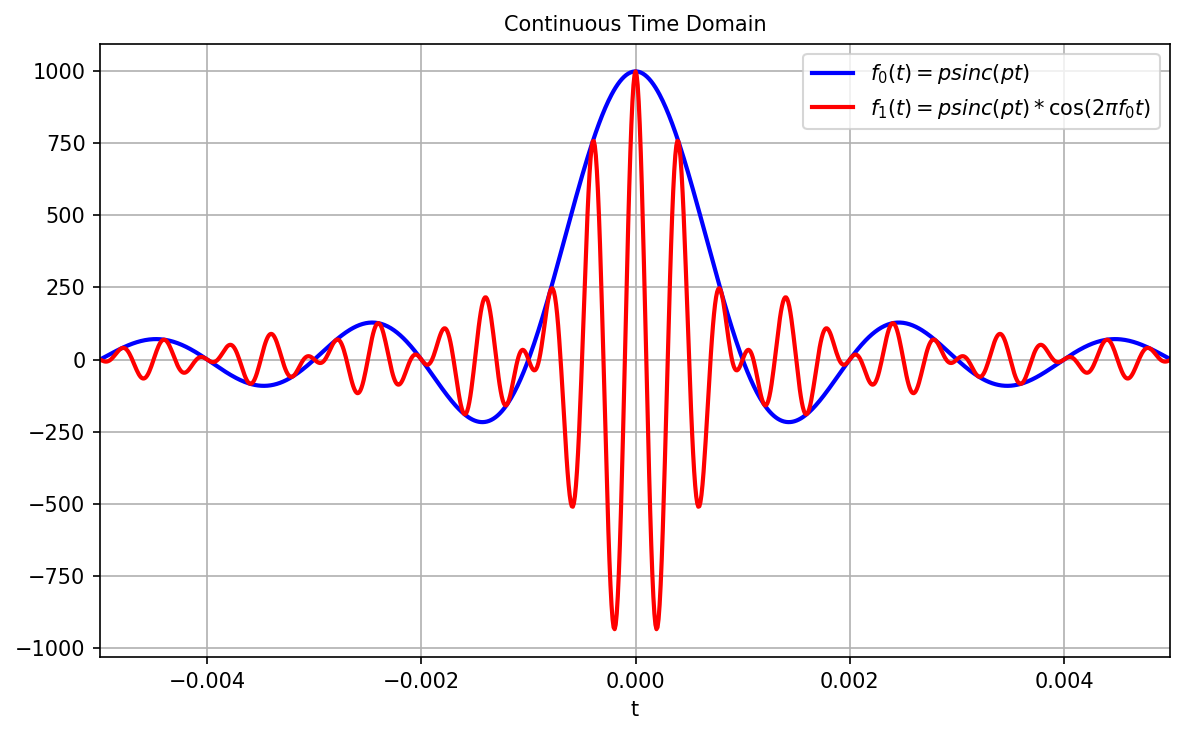

In [4]:
T = 0.01              # total time window length
N = 2**10             # number of samples
fs = N / T            # sampling frequency
Ts = 1 / fs
dt = Ts

t = np.arange(N)*Ts - T/2

f0 = 2500 # modulation frequency
p = 1000 # bandwidth of the sinc function (rect in frequency domain)

y0 = p*np.sinc(p*t) # would expect rect(f/p)
y1 = p*np.sinc(p*t) * np.cos(2*np.pi*f0*t) # would expect rect((f +/- f0)/p)

fig, axs = plt.subplots(1,figsize=(8,5), dpi=150)
axs.plot(t,y0,'b-',label=r'$f_0(t)=p sinc(pt)$')
axs.plot(t,y1,'r-',label=r'$f_1(t)=p sinc(pt)*\cos(2\pi f_0 t)$')
axs.set_xlim([min(t),max(t)])
axs.set_xlabel('t')
axs.set_title('Continuous Time Domain')
axs.legend()
plt.show()

In [5]:
# Take the FFT of the sampled signals (and scale by dt to get correct amplitude)
Y0_fft = fft(y0) * dt
Y1_fft = fft(y1) * dt 
freq = fftfreq(N, 1/fs)
fft_scale = np.max(np.abs(Y0_fft[0:int(N/2)]))


In [6]:
# rect function for plotting
def basic_rect(f,p):
    X = np.zeros_like(f)
    X[np.abs(f/p) <= 0.5] = 1
    return X

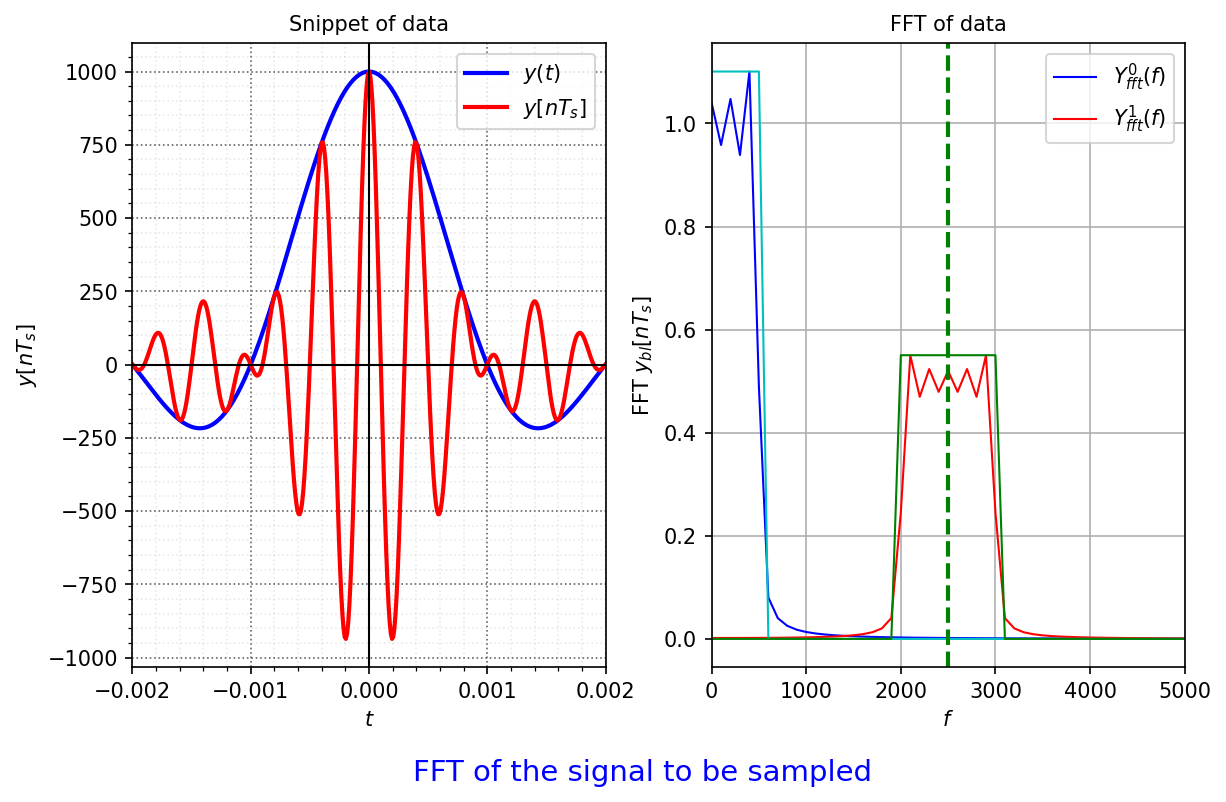

In [7]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,5), dpi=150)
fig.tight_layout(pad=2)
ax1.plot(t, y0, 'b-')
ax1.plot(t, y1, 'r-')
ax1.set_ylabel(r'$y[nT_s]$')
ax1.set_xlabel(r'$t$')
ax1.legend([r'$y(t)$', r'$y[nT_s]$'])
ax1.set_title('Snippet of data')
ax1.set_xlim([-2/p, 2/p])
bm.nicegrid(ax1)

ax2.plot(freq[0:int(N/2)],np.abs(Y0_fft[0:int(N/2)]),'b-',lw=1,label=r'$Y^0_{fft}(f)$')
ax2.plot(freq[0:int(N/2)],np.abs(Y1_fft[0:int(N/2)]),'r-',lw=1,label=r'$Y^1_{fft}(f)$')
ax2.plot(freq[0:int(N/2)],fft_scale*basic_rect(freq[0:int(N/2)],p),'c-',lw=1)
ax2.plot(freq[0:int(N/2)],fft_scale*basic_rect((freq[0:int(N/2)] - f0),p)/2,'g-',lw=1)
ax2.axvline(x = f0,color="green",ls='--')
ax2.set_ylabel(r'FFT $y_{bl}[nT_s]$')
ax2.set_xlabel(r'$f$')
ax2.set_xlim([0, 2*f0])
ax2.legend()
ax2.set_title('FFT of data')
bm.caption("FFT of the signal to be sampled",fig)
plt.show()